ESCENARIO 02 CLAUDE.IA - SIN REGLAS, VERSIÓN PAGA

REPORTE DE AVANCE FÍSICO Y VALOR GANADO (EVM)

Avance físico consolidado: 0.00%

Avance físico por disciplina:
  - Civil: 0.00%
  - Eléctrica: 0.00%
  - Instrumentación: 0.00%
  - Mecánica estática: 0.00%
  - Rotativa: 0.00%

Indicadores de Valor Ganado (EVM):
  PV  (Valor Planificado): 0.00
  EV  (Valor Ganado)     : 0.00
  AC  (Costo Real)       : 0.00
  SPI (Índice de Cronograma): N/A
  CPI (Índice de Costo)     : N/A

Interpretación:
  - SPI no calculable (PV = 0).
  - CPI no calculable (AC = 0).

----------------------------------------------------------------------
INCONSISTENCIAS DETECTADAS: 1532
----------------------------------------------------------------------
    1. [ID: GLOBAL] Columna faltante -> La columna 'peso_presupuestal' no existe en el archivo. Se asumió vacía/0 para poder continuar.
    2. [ID: GLOBAL] Columna faltante -> La columna 'costo_real' no existe en el archivo. Se asumió vacía/0 para poder continuar.
    3. [ID: STAP-ELE-019] ID duplicado -> El id_activ

/tmp/ipykernel_2845/4157173704.py:168: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context("mode.use_inf_as_na", True):
/tmp/ipykernel_2845/4157173704.py:204: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return calc.groupby("disciplina").apply(wavg)


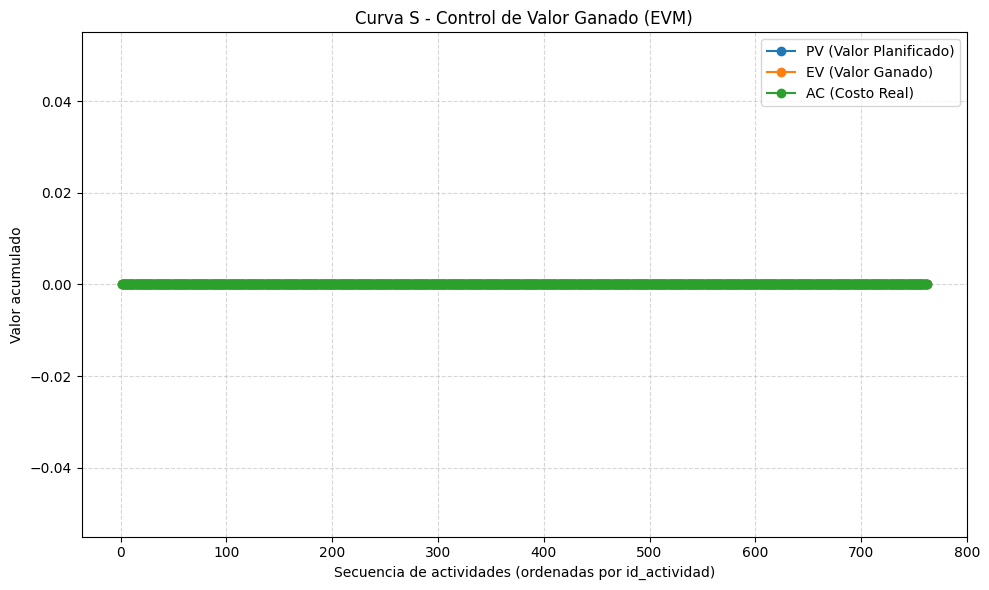

In [3]:
# =============================================================================
# CONTROL DE AVANCE FÍSICO Y VALOR GANADO (EVM) - OBRA DE CONSTRUCCIÓN
# -----------------------------------------------------------------------------
# Ejecutable directamente en una celda de Google Colab.
# Requiere el archivo "02_Dataset_Base_STAP.csv" en la misma carpeta de trabajo.
#
# COLUMNAS ESPERADAS EN EL CSV (nombres exactos, separado por comas, UTF-8):
#   id_actividad            -> identificador único de la actividad
#   disciplina              -> Civil, Mecánica estática, Rotativa,
#                              Instrumentación, Eléctrica
#   unidad                  -> pulg_diam, kg, m, m2, m3, und
#   peso_presupuestal       -> valor presupuestado de la actividad (BAC parcial)
#   cantidad_planificada    -> cantidad física planificada total
#   cantidad_ejecutada      -> cantidad física ejecutada a la fecha de corte
#   avance_planificado_pct  -> avance planificado a la fecha de corte [0,1]
#   costo_real              -> costo real incurrido a la fecha de corte (AC)
#
# Si el dataset no trae alguna columna necesaria para el cálculo, el programa
# la reporta como inconsistencia y usa un valor neutro (0) para no detenerse.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

ARCHIVO = "02_Dataset_Base_STAP.csv"

UNIDADES_VALIDAS = {"pulg_diam", "kg", "m", "m2", "m3", "und"}
DISCIPLINAS_VALIDAS = {"Civil", "Mecánica estática", "Rotativa",
                        "Instrumentación", "Eléctrica"}

COLUMNAS_REQUERIDAS = [
    "id_actividad", "disciplina", "unidad", "peso_presupuestal",
    "cantidad_planificada", "cantidad_ejecutada",
    "avance_planificado_pct", "costo_real",
]


# -----------------------------------------------------------------------------
# CARGA DE DATOS
# -----------------------------------------------------------------------------
def cargar_datos(ruta):
    try:
        df = pd.read_csv(ruta, encoding="utf-8", sep=",")
    except FileNotFoundError:
        raise FileNotFoundError(
            f"No se encontró el archivo '{ruta}'. Debe estar en la misma "
            f"carpeta que este notebook/script."
        )

    # Asegurar que existan todas las columnas necesarias (si falta alguna,
    # se crea vacía para poder continuar y reportar la inconsistencia).
    inconsistencias_columnas = []
    for col in COLUMNAS_REQUERIDAS:
        if col not in df.columns:
            df[col] = pd.NA
            inconsistencias_columnas.append(
                {"id_actividad": "GLOBAL",
                 "tipo": "Columna faltante",
                 "detalle": f"La columna '{col}' no existe en el archivo. "
                            f"Se asumió vacía/0 para poder continuar."}
            )
    return df, inconsistencias_columnas


# -----------------------------------------------------------------------------
# VALIDACIONES (no detienen el programa, solo se reportan)
# -----------------------------------------------------------------------------
def validar_datos(df):
    inconsistencias = []

    # Normalizar tipos numéricos, forzando errores a NaN
    for col in ["peso_presupuestal", "cantidad_planificada",
                "cantidad_ejecutada", "avance_planificado_pct", "costo_real"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # --- 1. id_actividad duplicado ---
    duplicados = df[df.duplicated("id_actividad", keep=False)]["id_actividad"].unique()
    for idact in duplicados:
        inconsistencias.append({
            "id_actividad": idact,
            "tipo": "ID duplicado",
            "detalle": "El id_actividad aparece más de una vez en el dataset."
        })

    # --- 2. cantidad ejecutada mayor que la planificada ---
    mask_sobre_ejecucion = df["cantidad_ejecutada"] > df["cantidad_planificada"]
    for idact in df.loc[mask_sobre_ejecucion, "id_actividad"]:
        inconsistencias.append({
            "id_actividad": idact,
            "tipo": "Sobre-ejecución",
            "detalle": "cantidad_ejecutada > cantidad_planificada. "
                       "Se limitó el avance físico de la actividad a 100% "
                       "para efectos de cálculo."
        })

    # --- 3. peso presupuestal nulo, negativo o ausente ---
    mask_peso_invalido = df["peso_presupuestal"].isna() | (df["peso_presupuestal"] <= 0)
    for idact in df.loc[mask_peso_invalido, "id_actividad"]:
        inconsistencias.append({
            "id_actividad": idact,
            "tipo": "Peso presupuestal inválido",
            "detalle": "peso_presupuestal nulo, ausente o negativo/cero. "
                       "La actividad se excluyó de los promedios ponderados."
        })

    # --- 4. unidad no reconocida ---
    mask_unidad_invalida = ~df["unidad"].astype(str).str.strip().isin(UNIDADES_VALIDAS)
    for idact in df.loc[mask_unidad_invalida, "id_actividad"]:
        inconsistencias.append({
            "id_actividad": idact,
            "tipo": "Unidad no reconocida",
            "detalle": f"Unidad '{df.loc[df['id_actividad'] == idact, 'unidad'].values[0]}' "
                       f"no está en la lista válida {sorted(UNIDADES_VALIDAS)}."
        })

    # --- 5. disciplina no reconocida ---
    mask_disciplina_invalida = ~df["disciplina"].astype(str).str.strip().isin(DISCIPLINAS_VALIDAS)
    for idact in df.loc[mask_disciplina_invalida, "id_actividad"]:
        inconsistencias.append({
            "id_actividad": idact,
            "tipo": "Disciplina no reconocida",
            "detalle": f"Disciplina '{df.loc[df['id_actividad'] == idact, 'disciplina'].values[0]}' "
                       f"no está en la lista válida {sorted(DISCIPLINAS_VALIDAS)}."
        })

    # --- 6. avance_planificado_pct fuera de rango [0,1] ---
    mask_avance_fuera_rango = (
        df["avance_planificado_pct"].isna()
        | (df["avance_planificado_pct"] < 0)
        | (df["avance_planificado_pct"] > 1)
    )
    for idact in df.loc[mask_avance_fuera_rango, "id_actividad"]:
        inconsistencias.append({
            "id_actividad": idact,
            "tipo": "avance_planificado_pct fuera de rango",
            "detalle": "El valor debe estar entre 0 y 1. Se limitó (clip) "
                       "al rango válido para el cálculo."
        })

    # --- 7. costo_real ausente o negativo (necesario para AC) ---
    mask_costo_invalido = df["costo_real"].isna() | (df["costo_real"] < 0)
    for idact in df.loc[mask_costo_invalido, "id_actividad"]:
        inconsistencias.append({
            "id_actividad": idact,
            "tipo": "Costo real inválido",
            "detalle": "costo_real ausente o negativo. Se asumió 0 para el cálculo de AC."
        })

    return df, inconsistencias, {
        "peso_invalido": mask_peso_invalido,
        "avance_fuera_rango": mask_avance_fuera_rango,
        "sobre_ejecucion": mask_sobre_ejecucion,
        "costo_invalido": mask_costo_invalido,
    }


# -----------------------------------------------------------------------------
# PREPARACIÓN DE DATOS PARA CÁLCULO (correcciones no destructivas)
# -----------------------------------------------------------------------------
def preparar_calculo(df, mascaras):
    calc = df.copy()

    # Avance planificado limitado a [0,1]
    calc["avance_planificado_pct"] = calc["avance_planificado_pct"].clip(lower=0, upper=1)
    calc["avance_planificado_pct"] = calc["avance_planificado_pct"].fillna(0)

    # Avance físico de cada actividad = ejecutada / planificada, limitado a 1
    with pd.option_context("mode.use_inf_as_na", True):
        calc["avance_actividad_pct"] = calc["cantidad_ejecutada"] / calc["cantidad_planificada"]
    calc["avance_actividad_pct"] = calc["avance_actividad_pct"].fillna(0)
    calc["avance_actividad_pct"] = calc["avance_actividad_pct"].clip(lower=0, upper=1)

    # Peso presupuestal: inválidos se tratan como 0 (no aportan a ponderaciones)
    calc["peso_presupuestal_calc"] = calc["peso_presupuestal"].where(
        ~mascaras["peso_invalido"], 0
    )

    # Costo real: inválidos se tratan como 0
    calc["costo_real_calc"] = calc["costo_real"].where(
        ~mascaras["costo_invalido"], 0
    )

    return calc


# -----------------------------------------------------------------------------
# INDICADORES DE AVANCE FÍSICO
# -----------------------------------------------------------------------------
def avance_consolidado(calc):
    peso_total = calc["peso_presupuestal_calc"].sum()
    if peso_total <= 0:
        return 0.0
    avance = (calc["avance_actividad_pct"] * calc["peso_presupuestal_calc"]).sum() / peso_total
    return avance * 100


def avance_por_disciplina(calc):
    def wavg(grupo):
        peso = grupo["peso_presupuestal_calc"].sum()
        if peso <= 0:
            return 0.0
        return (grupo["avance_actividad_pct"] * grupo["peso_presupuestal_calc"]).sum() / peso * 100

    return calc.groupby("disciplina").apply(wavg)


# -----------------------------------------------------------------------------
# VALOR GANADO (EVM)
# -----------------------------------------------------------------------------
def calcular_evm(calc):
    pv = (calc["peso_presupuestal_calc"] * calc["avance_planificado_pct"]).sum()
    ev = (calc["peso_presupuestal_calc"] * calc["avance_actividad_pct"]).sum()
    ac = calc["costo_real_calc"].sum()

    spi = ev / pv if pv > 0 else float("nan")
    cpi = ev / ac if ac > 0 else float("nan")

    return {"PV": pv, "EV": ev, "AC": ac, "SPI": spi, "CPI": cpi}


def interpretar_spi_cpi(spi, cpi):
    if pd.isna(spi):
        txt_spi = "SPI no calculable (PV = 0)."
    elif spi > 1:
        txt_spi = f"SPI = {spi:.2f} > 1 → el proyecto está ADELANTADO respecto al cronograma."
    elif spi < 1:
        txt_spi = f"SPI = {spi:.2f} < 1 → el proyecto está ATRASADO respecto al cronograma."
    else:
        txt_spi = f"SPI = {spi:.2f} = 1 → el proyecto está EXACTAMENTE en cronograma."

    if pd.isna(cpi):
        txt_cpi = "CPI no calculable (AC = 0)."
    elif cpi > 1:
        txt_cpi = f"CPI = {cpi:.2f} > 1 → el proyecto presenta AHORRO respecto al presupuesto."
    elif cpi < 1:
        txt_cpi = f"CPI = {cpi:.2f} < 1 → el proyecto presenta SOBRECOSTO respecto al presupuesto."
    else:
        txt_cpi = f"CPI = {cpi:.2f} = 1 → el proyecto está exactamente dentro del presupuesto."

    return txt_spi, txt_cpi


# -----------------------------------------------------------------------------
# CURVA S (PV, EV, AC acumulados)
# -----------------------------------------------------------------------------
def graficar_curva_s(calc):
    # No se dispone de columna de fecha en el dataset base, por lo que la
    # curva S se construye acumulando las actividades ordenadas por
    # id_actividad, como aproximación de la secuencia de ejecución.
    datos = calc.sort_values("id_actividad").copy()

    datos["PV_actividad"] = datos["peso_presupuestal_calc"] * datos["avance_planificado_pct"]
    datos["EV_actividad"] = datos["peso_presupuestal_calc"] * datos["avance_actividad_pct"]
    datos["AC_actividad"] = datos["costo_real_calc"]

    datos["PV_acum"] = datos["PV_actividad"].cumsum()
    datos["EV_acum"] = datos["EV_actividad"].cumsum()
    datos["AC_acum"] = datos["AC_actividad"].cumsum()

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(datos) + 1), datos["PV_acum"], label="PV (Valor Planificado)", marker="o")
    plt.plot(range(1, len(datos) + 1), datos["EV_acum"], label="EV (Valor Ganado)", marker="o")
    plt.plot(range(1, len(datos) + 1), datos["AC_acum"], label="AC (Costo Real)", marker="o")
    plt.title("Curva S - Control de Valor Ganado (EVM)")
    plt.xlabel("Secuencia de actividades (ordenadas por id_actividad)")
    plt.ylabel("Valor acumulado")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# REPORTE POR PANTALLA
# -----------------------------------------------------------------------------
def imprimir_reporte(avance_global, avance_disc, evm, inconsistencias):
    print("=" * 70)
    print("REPORTE DE AVANCE FÍSICO Y VALOR GANADO (EVM)")
    print("=" * 70)

    print(f"\nAvance físico consolidado: {avance_global:.2f}%")

    print("\nAvance físico por disciplina:")
    if len(avance_disc) == 0:
        print("  (sin datos)")
    else:
        for disciplina, valor in avance_disc.items():
            print(f"  - {disciplina}: {valor:.2f}%")

    print("\nIndicadores de Valor Ganado (EVM):")
    print(f"  PV  (Valor Planificado): {evm['PV']:.2f}")
    print(f"  EV  (Valor Ganado)     : {evm['EV']:.2f}")
    print(f"  AC  (Costo Real)       : {evm['AC']:.2f}")
    spi_txt = f"{evm['SPI']:.2f}" if not pd.isna(evm["SPI"]) else "N/A"
    cpi_txt = f"{evm['CPI']:.2f}" if not pd.isna(evm["CPI"]) else "N/A"
    print(f"  SPI (Índice de Cronograma): {spi_txt}")
    print(f"  CPI (Índice de Costo)     : {cpi_txt}")

    txt_spi, txt_cpi = interpretar_spi_cpi(evm["SPI"], evm["CPI"])
    print("\nInterpretación:")
    print(f"  - {txt_spi}")
    print(f"  - {txt_cpi}")

    print("\n" + "-" * 70)
    print(f"INCONSISTENCIAS DETECTADAS: {len(inconsistencias)}")
    print("-" * 70)
    if not inconsistencias:
        print("  No se detectaron inconsistencias.")
    else:
        for i, inc in enumerate(inconsistencias, start=1):
            print(f"  {i:>3}. [ID: {inc['id_actividad']}] {inc['tipo']} -> {inc['detalle']}")

    print("=" * 70)


# -----------------------------------------------------------------------------
# PROGRAMA PRINCIPAL
# -----------------------------------------------------------------------------
def main():
    df, inconsistencias_columnas = cargar_datos(ARCHIVO)
    df, inconsistencias_validacion, mascaras = validar_datos(df)
    inconsistencias = inconsistencias_columnas + inconsistencias_validacion

    calc = preparar_calculo(df, mascaras)

    avance_global = avance_consolidado(calc)
    avance_disc = avance_por_disciplina(calc)
    evm = calcular_evm(calc)

    imprimir_reporte(avance_global, avance_disc, evm, inconsistencias)
    graficar_curva_s(calc)


if __name__ == "__main__":
    main()